# **Machine learning: Reconnaissance de sorts (magiques)**

## 1. Introduction

### a) Rappels

Ce notebook fait suite au TP Perceptron dans lequel nous avions construit un petit réseau de neurones - appelé **perceptron** - pour effectuer de la reconnaissance de caractères.


<img src="https://github.com/PlantecJY/python-mic/raw/master/principe.png" alt="Drawing" width="300" align="center"/>


Nous avions suivi les étapes ci-dessous :
* **Structuration des données** pour l’apprentissage (un dictionnaire de chiffres écrits représentés par des tableaux 5*6, comme dans l'exemple ci-dessous

```
nb9b = [[1,1,1,1,1],
        [1,0,0,0,1],
        [1,0,0,0,1],
        [1,1,1,1,1],
        [0,0,0,0,1],
        [1,1,1,1,1]]
```
* **Création du réseau de neurones** : une couche d'entrée de dimension 300 et une couche de sortie de dimension 10 ; l'information passée à chaque neurone de sortie était simplement la combinaison linéaire des neurones reliés à cette sortie pondérée par le poids de chaque neurone ;
* **Test** du fonctionnement du réseau de neurones ;
* **Apprentissage**, c'est-dire-optimisation du poids de chaque neurone ;
* Utilisation du réseau de neurones pour une faire une **prédiction** : on fournit un chiffre sous forme de tableau et on demande au réseau de prédire ce chiffre.

### b) Objectif de ce TP

Dans ce TP, l'objectif est de comprendre toute la **chaîne d'apprentissage en Machine Learning** à travers le domaine de la **reconnaissance de gestes**, et plus particulièrement de sorts (magiques). Nous allons donc passer par les étapes suivantes:
  1) Acquisition des données brutes et construction d'un **dataset**
  2) **Split** données d'entraînement/ données de test
  3) **Pré-traitement** des données (génération de features)
  4) **Entraînement** d'un modèle léger (réseau de neurones)
  5) **Test** du modèle
  6) **Déploiement embarqué** sur une carte

 
### c) Etapes à suivre

1) **PARTIE 1**: Comprendre toute la chaîne d'apprentissage à travers un dataset déjà prêt
2) **PARTIE 2**: Déploiement embarqué sur carte du modèle
3) **PARTIE 3**: Compléter la base de donnée: ajoutez un nouveau geste et refaire la chaîne d'apprentissage jusqu'au déploiement.

## **PARTIE 1: Comprendre la chaîne d'apprentissage en machine learning**

## 1. Construction d'un dataset

Pour cette première étape, nous allons télécharger une base de données contenant déjà un certains nombre de gestes par **label** (qui sont au nombre de 3):
* 100 gestes du sort "**Wingardium Leviosa**"
* 100 gestes du sort "**Stupefy**"
* 100 gestes du sort "**Expelliarmus**"

Les gestes sont enregistrés, carte à la main, pendant une durée de **5 secondes**, il est important de respecter ce temps d'acquisition pour l'enregistrement de nouvelles données.

L'objectif ici est de construire un tableau sur Python contenant les données que l'on pourra ensuite traîter pour entraîner/tester le modèle futur.


### a) Importation des fichiers/bibilothèques nécessaires

In [1]:
#Une fois cette ligne executée, Restart Kernel

%pip install pyserial

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import zipfile
import os
import glob
import json
import pandas as pd
import os

### b) Upload d'un dataset et rangement des données dans un tableau

Remarque: ici, les données sont dites "**brutes**", elles ne sont pas encore traitées pour entraîner et tester le modèle, on a ici les acquisitions temporelles de chaque enregistrements de gestes, ce qui donne beaucoup plus de lignes sur le tableau que de fichiers réels.

In [3]:
data = pd.read_csv("dataset_sorts_xiao.csv")

colonnes_attendues = [
    "AxX", "AxY", "AxZ",
    "GxX", "GxY", "GxZ",
    "source_file", "label", "origine",
]

colonnes_manquantes = set(colonnes_attendues) - set(data.columns)
if colonnes_manquantes:
    raise ValueError(f"Colonnes manquantes : {colonnes_manquantes}")

print("Taille du dataset :", data.shape)
display(
    data.groupby("label")["source_file"]
    .nunique()
    .rename("nombre_de_gestes")
    .to_frame()
)

data.head()


Taille du dataset : (75157, 9)


,nombre_de_gestes
label,
Expelliarmus,100
Stupefy,100
Wingardium Leviosa,100


,AxX,AxY,AxZ,GxX,GxY,GxZ,source_file,label,origine
0,-0.417240,-0.122488,0.926712,0.07,-2.31,-1.47,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
1,-0.410408,-0.142496,0.925736,-0.63,-1.12,-1.12,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
2,-0.417728,-0.147376,0.917928,0.21,-0.77,-0.07,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
3,-0.410896,-0.139080,0.936472,-0.98,-1.33,0.63,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
4,-0.404552,-0.135664,0.916952,1.75,0.98,1.61,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao


### c) Questions

1) Quelle est la fréquence d'enregistrement des données? Aidez vous de la taille du dataset, du nombre total d'enregistrements et du nombre de secondes d'un enregistrement. (valeur) Arrondir à la valeur entière la plus proche.
2) Que contient le fichier data_sort? (questions à choix multiples)
3) Quelle est la taille du dataset? (valeur)
4) Quelle est la valeur de l'axe Z du gyroscope de la première ligne du tableau de données? Aidez vous de la fonction head. (valeur)
5) Pourquoi est-il important de vérifier la qualité des données avant de commencer l'entraînement d'un modèle ? (questions à choix multiples)
6) Label-->Nom du geste enregistré; Acquisition-->Série de mesures IMU; Dataset-->Ensemble des acquisitions; Feature-->Caractéristique calculée après traitement (Association)

## 2. Split des données en training/test

Dans la deuxième étape de la chaîne d'apprentissage, on va **séparer (split)** les données en 2 catégories:
* Les **données d'entraînement** (training set) qui vont servir à entraîner le modèle, ces données seront elles-mêmes divisées en données d'entraînement et de validation du modèle
* Les **données de test** (test set) qui vont servir à tester le modèle une fois qu'il est entraîné

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/split.jpg" alt="Drawing" width="300" align="center"/>

### a) Importation des fichiers/bibilothèques nécessaires

In [4]:
import split_data

### b) Réalisation du split

In [5]:
#Exemple : 40 % des données pour le test
#train_data, test_data = split_data.split_dataset(data, test_size=0.40)

#Votre code ici pour un split de 75/25:
train_data, test_data = split_data.split_dataset(data, test_size=0.25)

Pourcentage de test demandé : 25%
Nombre de lignes training : 56375
Nombre de lignes testing : 18782
Shape training : (56375, 9)
Shape testing : (18782, 9)

Répartition par label :


,Training,Testing,Total,% Test
label,,,,
Expelliarmus,75,25,100,25.0
Stupefy,75,25,100,25.0
Wingardium Leviosa,75,25,100,25.0


### c) Graphique de la répartition des données

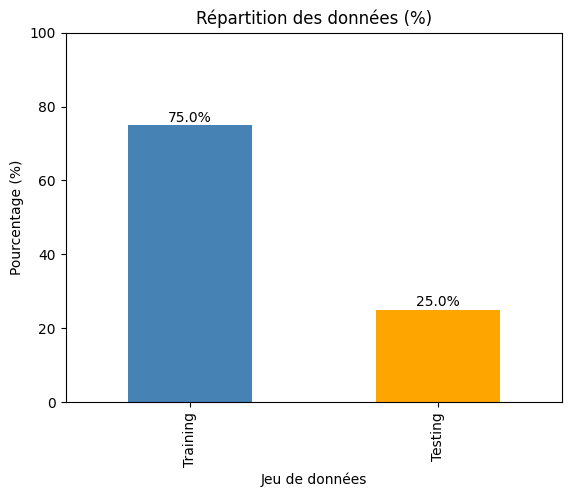

In [6]:
split_data.plot_data_split(train_data, test_data)

### d) Graphique de la répartition des données par LABEL

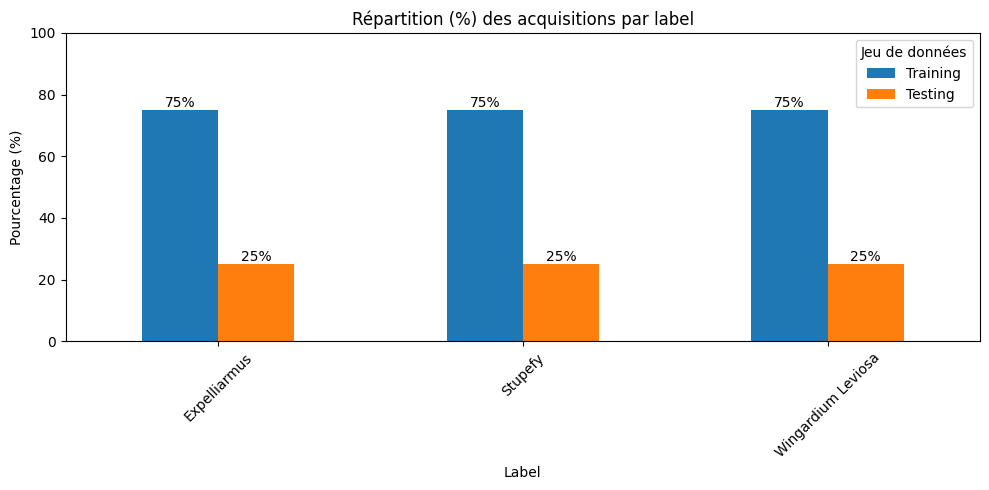

In [7]:
split_data.plot_label_split(train_data, test_data)

### e) Questions

1) Faire le split avec un pourcentage de 25% de données de test, donnez ensuite le nombre de lignes des données de test (valeur)
4) Pourquoi mélanger les données avant le split ? (Questions à choix multiples)
5) Pourquoi est-il important d'avoir des données que le modèle n'a jamais vu? (Questions à choix multiples)
6) Le jeu de test doit servir à entraîner le modèle (vrai ou faux)
8) Si on possède 300 acquisitions et que l'on a un split de 80/20, combien d'acquisitions sont utilisées pour l'entraînement ? (valeur)
9) Training--> apprentissage; validation --> réglage des hyperparamètres; test--> évaluation finale (association)

## 3. Analyse spectrale d'une donnée

Dans cette section, nous allons réaliser **l'analyse spectrale** d'une donnée en particulier. Nous allons d'abord observer son **image temporelle** pour ensuite l'analyser grâce à une **transformée de Fourier rapide (FFT)**. Cela nous permettra ensuite de générer des caractéristiques (**features**) pour toutes les données que l'on pourra utiliser pour entraîner et tester le modèle.


### a) Importation des fichiers/bibilothèques nécessaires

In [8]:
import analyse_spec

### b) Image temporelle de la donnée brute

In [9]:
#Choix d'une fonction à analyser

# Exemple d'utilisation de la fonction choisir_acquisition

sample = analyse_spec.choisir_acquisition(train_data, "Stupefy", 10)

#Votre code ici:



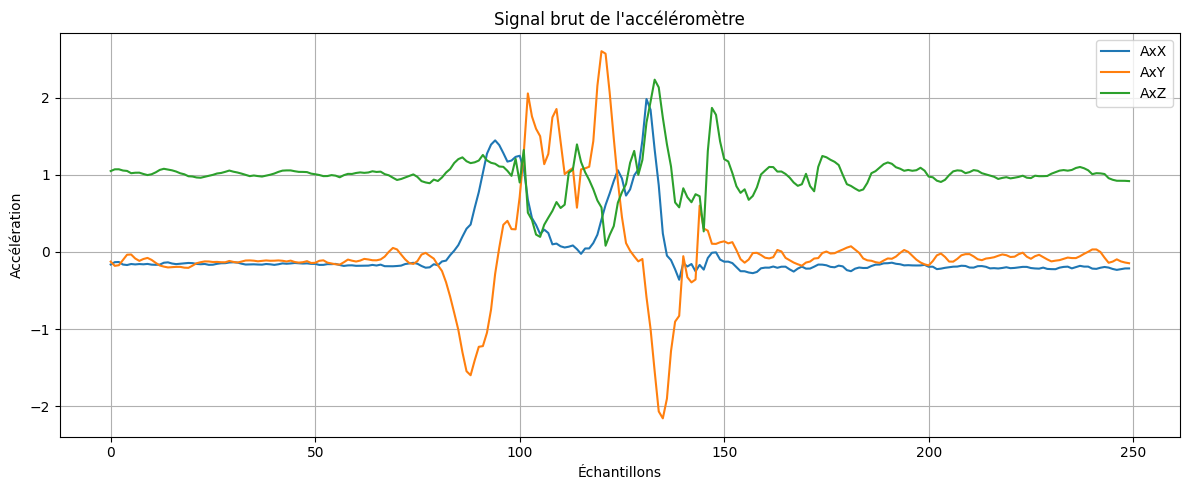

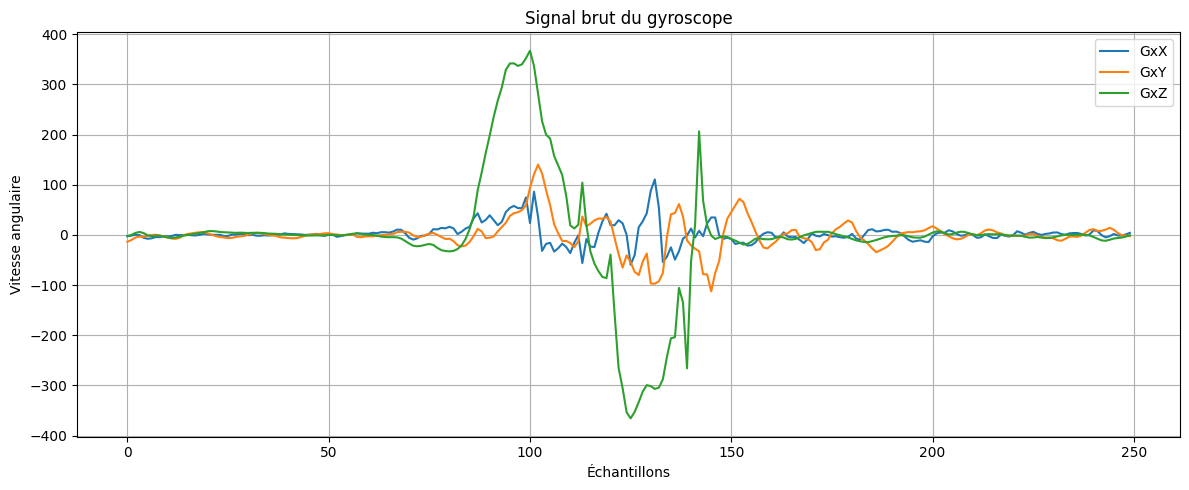

In [10]:
# Image en temporel de la donnée brute (accéléromètre)

analyse_spec.afficher_signaux_temporels(sample)

### c) Analyse spectrale de la donnée

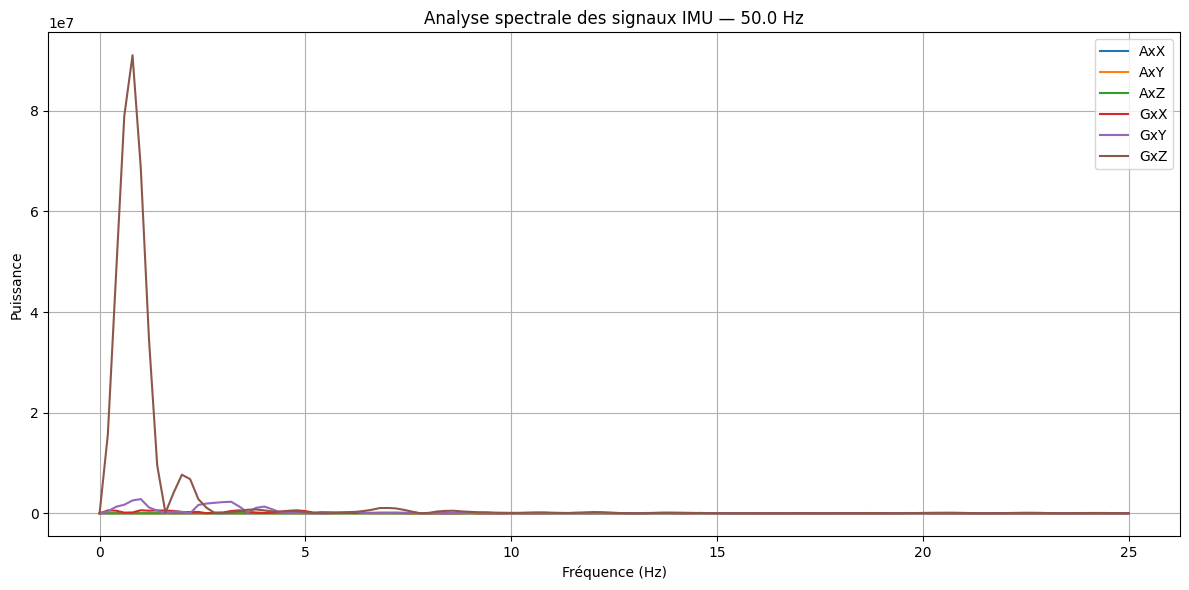

In [11]:
# Analyse spectrale (FFT)

resultats_fft = analyse_spec.afficher_analyse_spectrale(
    sample,
    interval_ms=20,
)

### d) Questions

1) Pourquoi il est préférable de faire une analyse fréquentielle plutot qu'une analyse temporelle dans ce cas de figure? (Questions à choix multiples)
2) Quel type de filtre appliqueriez vous en observant l'analyse spectrale du signal Expelliarmus numéro 0? (choix unique) 
3) Determinez l'intervalle de temps "intervalle_ms" pour avoir la bonne fréquence d'échantillonage correspondant à la carte Seeed Xiao NRF52840 sense.
6) Sur le sort "Wingardium Leviosa" de numéro 2, quel est l'axe de l'IMU prédominant vers 2Hz? (choix unique)
7) Comment le bruit influence-t-il le spectre fréquentiel ? (questions à choix mutliples)

## 4. Pré-traitement des données et génération de features

Ici, nous allons réaliser le **pré-traitement des données** avant l'entraînement du modèle:
* Nous allons d'abord réaliser un **split des données d'entraînement** en 2: celles qui vont servir à entraîner le modèle (**training set**) et celles qui vont servir à le valider (**validation set**).
* Ensuite, nous allons réaliser l'analyse spectrale de toutes les données pour permettre la **génération de caractéristiques** (features) qui vont servir pour l'entraînement et le test.
* Nous allons également réaliser quelques traitements sur les features avant leur utilisation.

### a) Importation des fichiers/bibilothèques nécessaires

In [12]:
import pretraitement

### b) Split train/validation

In [13]:
#Fonction qui réalise le split train/validation

# Exempele deuxième découpage : Train / Validation à 60/40
"""train_data, validation_data = pretraitement.split_train_validation(
    train_data,
    validation_size=0.4
)"""

#Votre code ici:

train_data, validation_data = pretraitement.split_train_validation(
    train_data,
    validation_size=0.2
)

Pourcentage de validation demandé : 20%
Nombre de lignes entraînement : 45101
Nombre de lignes validation : 11274

Répartition par label :


,Training,Validation,Total,% Validation
label,,,,
Expelliarmus,60,15,75,20.0
Stupefy,60,15,75,20.0
Wingardium Leviosa,60,15,75,20.0


### c) Génération des caractéristiques pour toutes les données

In [14]:
# Génération des features pour les trois jeux de données
features_train = pretraitement.construire_features(train_data)

#Votre code ici:
features_validation = pretraitement.construire_features(validation_data)
features_test = pretraitement.construire_features(test_data)

### d) Codage et normalisation des features

Ici, avant l'entraînement du modèle, il est important de **coder et normaliser** les caractéristiques pour permettre un entraînement optimal et efficace.

In [15]:
#Codage et normalisation des features

donnees_preparees = pretraitement.preparer_donnees_modele(
    features_train,
    features_validation,
    features_test,
)

X_train = donnees_preparees["X_train"]
X_validation = donnees_preparees["X_validation"]
X_test = donnees_preparees["X_test"]

y_train = donnees_preparees["y_train"]
y_validation = donnees_preparees["y_validation"]
y_test = donnees_preparees["y_test"]

X_train_scaled = donnees_preparees["X_train_scaled"]
X_validation_scaled = donnees_preparees["X_validation_scaled"]
X_test_scaled = donnees_preparees["X_test_scaled"]

y_train_encoded = donnees_preparees["y_train_encoded"]
y_validation_encoded = donnees_preparees["y_validation_encoded"]
y_test_encoded = donnees_preparees["y_test_encoded"]

label_encoder = donnees_preparees["label_encoder"]
scaler = donnees_preparees["scaler"]

Classes : ['Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Nombre de features : 138
Dimensions entraînement : (180, 138)
Dimensions validation : (45, 138)
Dimensions test : (75, 138)


### e) Questions

1) Faire le split train/validation à 80/20, combien y-a-t-il de lignes pour les données de validation? (valeur)
2) Quelle est la différence entre les données de test et les données de validation? (choix unique)
3) Faire la génération des features pour les 2 jeux de données de validation et de tests en suivant l'exemple de celui de "features_train": utilisez les appelations "features_validation" et "features_test" (partie à compléter)
5) Pourquoi est-il important de pré-traiter les données avant l'entraînement? (questions à choix multiples)
6) Pourquoi est-il important de normaliser les features? (choix unique)
7) Pourquoi faut-il coder les features avant l'entraînement? (choix unique)
9) Associez chacune de ses méthodes à leur definitions: Hold-Out, K-Fold et Leave-One-Out (association)

## 5. Classification sur données d'entraînement

Nous passons maintenant à la partie de l'**entraînement du modèle** avec **un réseau de neurones**, grâce aux données d'entraînement. 

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/reseau_neurones.png"
     alt="Réseau de neurones"
     width="600">

Cela nous permettra ensuite d'observer les **performances du modèle** (métriques, matrice de confusion) avec les données de validation qui serviront à régler le modèle et l'ajuster.

### a) Importation des fichiers nécessaires

In [16]:
import entrainement

### b) Création du réseau de neurones

In [17]:
#Architecture du réseau de neurones

num_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

model = entrainement.Sequential([
    entrainement.Dense(64, activation="relu", input_shape=(num_features,)),
    entrainement.Dropout(0.3),

    entrainement.Dense(32, activation="relu"),
    entrainement.Dropout(0.3),

    entrainement.Dense(num_classes, activation="softmax")
])

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### c) Compilation du modèle

In [18]:
# Compilation du modèle

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### d) Entraînement du modèle

In [19]:
#Entraînement 

early_stop = entrainement.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_data=(X_validation_scaled, y_validation_encoded),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5556 - loss: 0.9931 - val_accuracy: 0.9778 - val_loss: 0.4442
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9167 - loss: 0.4024 - val_accuracy: 1.0000 - val_loss: 0.1651
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9889 - loss: 0.1851 - val_accuracy: 1.0000 - val_loss: 0.0678
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9889 - loss: 0.1071 - val_accuracy: 1.0000 - val_loss: 0.0301
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0521 - val_accuracy: 1.0000 - val_loss: 0.0158
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9944 - loss: 0.0588 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0378 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9944 - loss: 0.0301 - val_accuracy: 1.0000 - val_loss

### e) Performances de l'entraînement

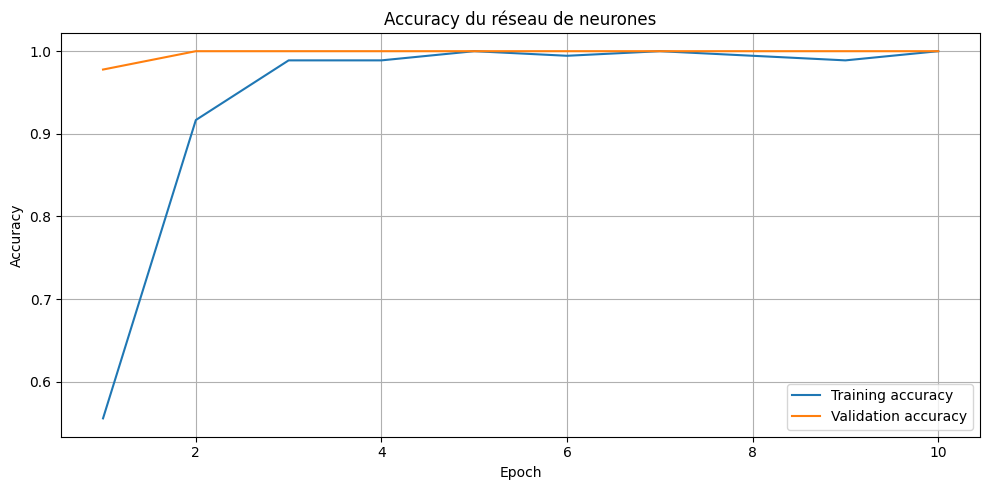

In [20]:
#Graphique de l'accuracy

entrainement.afficher_accuracy(history)

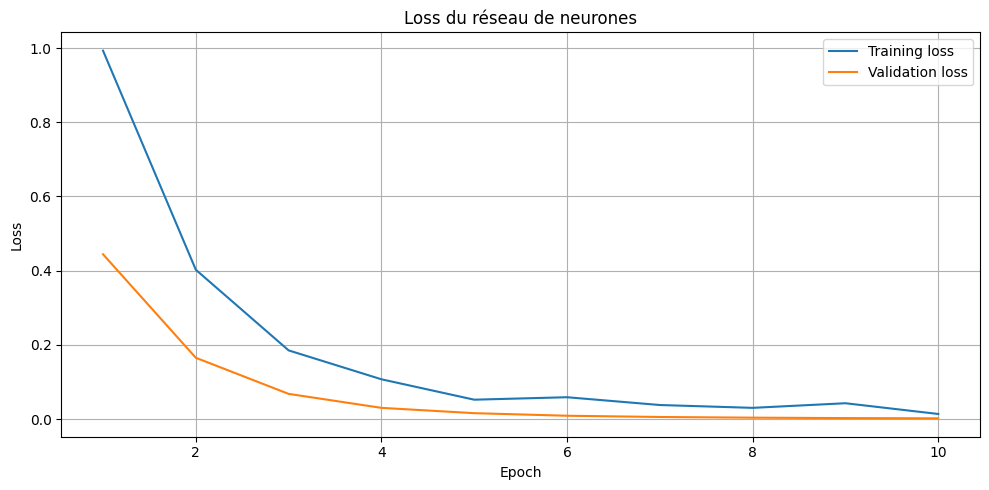

In [21]:
#Graphique de la fonction de perte du modèle

#Votre code ici:
entrainement.afficher_loss(history)

In [22]:
# Prédictions sur le jeu de validation
y_validation_proba = model.predict(X_validation_scaled)
y_validation_pred = entrainement.np.argmax(y_validation_proba, axis=1)

#Métriques

metrics_validation = entrainement.afficher_metriques_classification(
    y_validation_encoded,
    y_validation_pred,
    y_validation_proba,
    titre="Métriques - Validation",
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Métriques - Validation


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


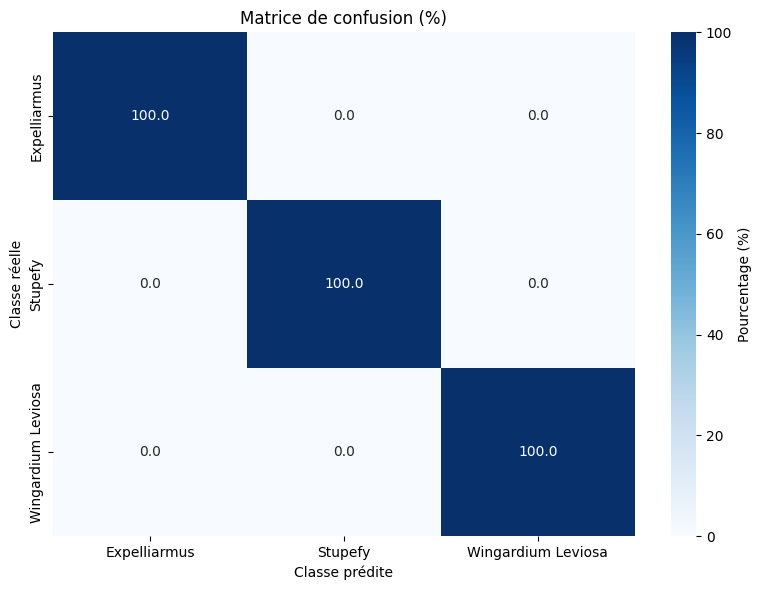

In [23]:
#Matrice de confusion

entrainement.afficher_matrice_confusion(
    y_validation_encoded,
    y_validation_pred,
    label_encoder.classes_
)

### f) Questions

1) Combien de couches contient le réseau? Analysez l'architecture du réseau de neurone. (valeur)
2) Quelle est la fonction d'activation utilisée pour la sortie du réseau de neurone? (Réponse rédigée)
3) Compilez et entraînez le modèle. Sur quoi le nombre d'époques a une/des conséquence(s)? (choix multiples)
4) Afficher la fonction de perte du réseau avec la fonction "entrainement.afficher_loss()", suivez l'exemple de la fonction permettant d'afficher l'accuracy.
5) Associez chaque métriques à sa définition (association)
6) Afficher la matrice de confusion.
7) Calculez l'accuracy du modèle grâce à la matrice de confusion avec epochs=20 (valeur)
8) Comment obtenir la probabilité de détection et le ratio de faux positifs avec la matrice de confusion? (choix unique)
9) Quel est le rôle de la fonction d'activation ? (choix unique)
10) Comment détecter un surapprentissage à partir des courbes d'entraînement et de validation ? (choix mutliples)

## 6. Test du modèle

Pour cette dernière étape avant le déploiement embarqué sur carte du modèle, nous allons **tester le modèle** avec les données qu'il n'a jamais vu, les **données de test**. Ce test permettra d'avoir les **performances réelles du modèle** quand on lui présente de nouvelles données qui ne lui ont pas servi pour s'entraîner.

### a) Importation des fichiers/bibliothèques nécessaires

In [24]:
import entrainement

### b) Codage et normalisation des features

Ici, avant le test du modèle, il est important de **coder et normaliser** les caractéristiques pour permettre un test optimal et efficace.

In [25]:
# Données de test

X_test = features_test.drop(
    columns=["source_file", "label"]
)

y_test = features_test["label"]

# Encodage des labels
y_test_encoded = label_encoder.transform(y_test)

# Normalisation des caractéristiques
X_test_scaled = scaler.transform(X_test)

### c) Prédicition du modèle sur les données de test

In [26]:
# Prédictions sur le jeu de test
y_test_proba = model.predict(X_test_scaled)
y_test_pred = entrainement.np.argmax(y_test_proba, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


### d) Performance du modèle

In [27]:
metrics_test = entrainement.afficher_metriques_classification(
    y_test_encoded,
    y_test_pred,
    y_test_proba,
    titre="Métriques - Test",
)

Métriques - Test


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


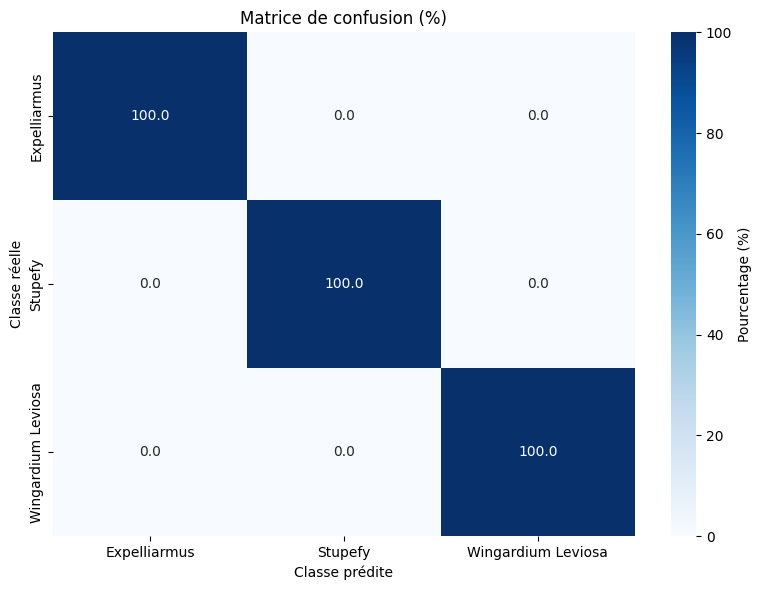

In [28]:
#Matrice de confusion

entrainement.afficher_matrice_confusion(
    y_test_encoded,
    y_test_pred,
    label_encoder.classes_
)

### e) Questions

1) Afficher la matrice de confusion et les métriques.
3) Analysez la matrice de confusion: Sur quels labels faut-il jouer pour améliorer la performance du modèle? (questions à choix multiples)
4) Pourquoi l'accuracy du test est-elle plus basse que celle de la validation lors de l'entraînement? (choix unique)
5) Que représentent les faux positifs? et les faux négatifs ? (choix unique)
6) Une accuracy de 100% garantit un modèle parfaitement fiable (vrai ou faux)

## **PARTIE 2: Déploiement du modèle sur la carte Seeed XIAO nRF52840 Sense**

Nous allons embarquer le réseau de neurones sur la carte Seeed Xiao NRF52840 Sense. Le notebook **exporte simplement les poids et les biais appris dans un fichier C++** (`model_params.h`). Sur la carte, une fonction C++ calcule directement les couches denses, les activations ReLU puis le softmax.

Le déroulement ensuite pour l'acquisition directe sur la carte est le suivant :

1. acquisition de mesures IMU à 50 Hz (fenêtre de 5 s) ;
2. calcul des mêmes caractéristiques que pendant l'entraînement ;
3. normalisation avec les paramètres du `StandardScaler` ;
4. inférence C++ : couche dense 138→32, ReLU, couche dense 32→16, ReLU, couche dense 16→classes, softmax ;
5. affichage de la classe et clignotement de la LED.

**Voici les étapes à suivre**: 
* Branchez la carte de la baguette magique à l'ordinateur via le cable USB
* IL EST IMPORTANT QUE L'ALIMENTATION SOIT EN MODE OFF
* Réalisez ensuite les étapes qui suivent pour charger le modèle sur la carte et le tester sans le branchement à l'ordinateur

### a) Présentation de la carte Seeed Xiao NRF52840 sense

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/Seeed-Studio-XIAO-nRF52840-Sense.jpg" width="300">

La carte **Seeed Xiao NRF52840 sense** est équipée d'un **IMU** (Inertial Measurement Unit), qui renvoie les données d'un **gyroscope** (sur 3 axes) et d'un **accéléromètre** (sur 3 axes), cela nous permettra d'analyser les gestes réalisées.

Nous allons donc charger le modèle que nous avons entraîné sur cette carte, nous allons ensuite dans la PARTIE 3 enregistrer de nouvelles données grâce à celle-ci.

### b) Importation des fichiers/bibliothèques nécessaires

In [29]:
import deploiement

### c) Installation du support de la carte Seeed Xiao NRF52840 Sense

In [30]:
ARDUINO_CLI = deploiement.installer_support_xiao_nrf52840()

Arduino CLI détecté : .\arduino-cli.EXE
Vérification d'Arduino CLI...
arduino-cli  Version: 1.5.1 Commit: 01f3d4f2b Date: 2026-06-05T10:22:12Z

Vérification d'Arduino CLI réussie.
Mise à jour de l'index Seeed Studio...
Mise à jour de l'index Seeed Studio réussie.
Installation du support XIAO nRF52840...
Installation du support XIAO nRF52840 réussie.
Vérification des supports installés...
Vérification des supports installés réussie.

Support de la Seeed XIAO nRF52840 correctement installé.


### d) Installation des bibliothèques Arduino nécessaires

In [31]:
deploiement.installer_bibliotheque_lsm6ds3(
    ARDUINO_CLI
)

Installation de la bibliothèque « Seeed Arduino LSM6DS3 »...
Bibliothèque Seeed Arduino LSM6DS3 installée.


True

### e) Export des paramètres du modèle

In [32]:
deploiement.exporter_modele_cpp(
    model,
    scaler,
    label_encoder,
)

Fichier généré : \\netapp2\bassant-koum\Stage IA\Jupyter notebook\Sujet TP\model_params.h
Architecture : 138 -> 64 -> 32 -> 3
Labels : ['Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Paramètres exportés : 11075
Mémoire approximative des poids en float32 : 43.3 Kio


WindowsPath('//netapp2/bassant-koum/Stage IA/Jupyter notebook/Sujet TP/model_params.h')

### f) Déploiement du modèle sur carte

Ici, nous allons générer un **code Arduino contenant le modèle** qui sera implémenté sur la carte.

In [33]:
# ============================================================
# Génération, compilation et téléversement du sketch Arduino
# Inference directe en C++ : Dense + ReLU + Softmax
# ============================================================

informations_deploiement = deploiement.deployer_modele_xiao(
    arduino_code=deploiement.arduino_code,
    arduino_cli=ARDUINO_CLI,
    fichier_parametres="model_params.h",
)

Sketch généré : C:\temp\deploiement_xiao_cpp\deploiement_xiao_cpp.ino
Carte détectée : COM10 - Périphérique série USB (COM10)
Compilation en cours...
Compilation réussie.
Téléversement en cours...
Téléversement réussie.
Modèle correctement téléversé sur COM10
Ouverture du moniteur série...
Interrompez la cellule pour le fermer.

XIAO prete - inference C++ directe.
Correspondance labels / clignotements :
Expelliarmus : 1 clignotement
Stupefy : 2 clignotements
Wingardium Leviosa : 3 clignotements
Preparez le geste...

Moniteur série arrêté.


## **Testez maintenant le modèle en débranchant la carte et en allumant l'alimentation! (Faites des batailles de sort avec la baguette magique :))**

### g) Questions

1) Pourquoi on parle de modèle « embarqué » ? (choix multiples)
2) Quel contient le fichier `model_params.h`? (choix unique)
3) Le même pré-traitement doit être appliqué en Python et sur la carte (vrai ou faux)
8) Quelles contraintes de mémoire et de temps de calcul que l'on peut rencontrer? (questions à choix multiples)
9) Pourquoi la cadence réelle d'acquisition doit-elle rester proche de 50 Hz ? (questions à choix multiples)


## **PARTIE 3 : Ajouter un nouveau geste par fine-tuning**

Cette partie réalise toute la boucle d'amélioration du système :

1. remplacer temporairement le modèle embarqué par un firmware d'acquisition ;
2. enregistrer plusieurs exemples d'un nouveau label pendant 5 secondes à 50 Hz ;
3. adapter le modèle déjà entraîné en partie 1 sans repartir de poids aléatoires ;
4. exporter les nouveaux poids en C++ et ré-embarquer le modèle comme en partie 2.

Le fine-tuning consiste à reprendre un modèle déjà entraîné sur les anciens gestes et à l’entraîner encore un peu avec le nouveau geste.

Le modèle conserve ainsi ce qu’il a déjà appris, tout en adaptant ses paramètres pour reconnaître une classe supplémentaire. Pendant cette étape, il faut également lui présenter des exemples des anciens gestes afin qu’il ne les oublie pas.

Le fine-tuning réutilise le prétraitement, le `StandardScaler` et les couches cachées de la partie 1. La couche de sortie est agrandie afin d'ajouter le nouveau label. Les anciennes données sont mélangées aux nouvelles pour limiter l'oubli des sorts déjà connus.


## 1. Charger le firmware d'acquisition sur la carte

Le modèle de classification est temporairement remplacé par un programme simple. Lorsque Python envoie la commande `S`, la carte renvoie 250 mesures IMU, soit 5 secondes à 50 Hz, puis envoie `FIN`.

Les trois LED restent allumées pendant l'acquisition.


### a) Importation des fichiers/bibliothèques nécessaires

In [34]:
import nouveau_label

### b) Téléversement du firmware d'acquisition 

In [35]:
# Téléversement du firmware d'acquisition de nouvelles données

PORT = nouveau_label.charger_firmware_acquisition_xiao()

Arduino CLI détecté : .\arduino-cli.EXE
Sketch d'acquisition généré : C:\temp\acquisition_xiao\acquisition_xiao.ino
Carte détectée : COM10 - Périphérique série USB (COM10)
Compilation du firmware d'acquisition en cours...
Compilation du firmware d'acquisition réussie.
Téléversement du firmware d'acquisition en cours...
Téléversement du firmware d'acquisition réussie.
Carte prête pour les acquisitions sur COM10


## 2. Enregistrer le nouveau label

Choisissez **Créer un nouveau label**, puis enregistrez idéalement au moins 20 acquisitions. Réalisez toujours le même geste, avec des variations naturelles de vitesse, d'orientation et d'amplitude.

### a) Importation des fichiers/bibliothèques nécessaires

In [36]:
import nouvelle_acquisition
import deploiement

### b) Lancer le menu d'acquisition

In [38]:
data = nouvelle_acquisition.menu_acquisition(
    dataset=data,
    fonction_trouver_port=nouvelle_acquisition.trouver_port_xiao,
)



===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Enregistrer plusieurs acquisitions
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition XIAO
5 - Afficher les labels
6 - Terminer


Choix :  5


,nombre_acquisitions
label,
Bli,5
Expelliarmus,100
Stupefy,100
Wingardium Leviosa,100


### c) Questions sur l'acquisition

1. Pourquoi faut-il conserver une fenêtre de 5 secondes et une fréquence de 50 Hz ? (choix unique)
2. Combien de gestes faut-il idéalement pour le nouveau label? (valeur)
3. Pourquoi faut-il varier légèrement la vitesse et l'orientation sans changer la nature du geste ? (choix unique)
4. Pourquoi les anciennes classes doivent-elles être présentes pendant le fine-tuning ? (choix unique)


## 3. Fine-tuning du modèle de la partie 1

Cette étape ne recrée pas un réseau à partir de zéro :

- les deux couches cachées et leurs poids sont repris du modèle de la partie 1 ;
- la couche de sortie est agrandie ;
- les poids de sortie des anciens labels sont recopiés par nom ;
- le nouveau neurone de sortie est initialisé ;
- la tête est d'abord entraînée seule, puis tout le réseau est ajusté avec un faible taux d'apprentissage.

Le scaler de la partie 1 est conservé : le recalculer changerait la signification numérique des entrées et rendrait les anciens poids incohérents.


### a) Importation des fichiers/bibliothèques nécessaires

In [45]:
import importlib
import nouveau_label
import pretraitement

importlib.reload(nouveau_label)

<module 'nouveau_label' from 'U:\\Stage IA\\Jupyter notebook\\Sujet TP\\nouveau_label.py'>

Phase 1/2 : adaptation de la couche de sortie
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9846 - loss: 0.8229 - val_accuracy: 0.9796 - val_loss: 0.0489
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9846 - loss: 1.0084 - val_accuracy: 0.9796 - val_loss: 0.0470
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9897 - loss: 0.5403 - val_accuracy: 0.9796 - val_loss: 0.0443
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9846 - loss: 0.5798 - val_accuracy: 0.9796 - val_loss: 0.0412
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9846 - loss: 0.8379 - val_accuracy: 0.9796 - val_loss: 0.0390
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9846 - loss: 0.6204 - val_accuracy: 0.9796 - val_loss: 0.0370
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9795 - loss: 0.7724 - val_accuracy: 0.9796 - val_loss: 0.0354
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9795 - 

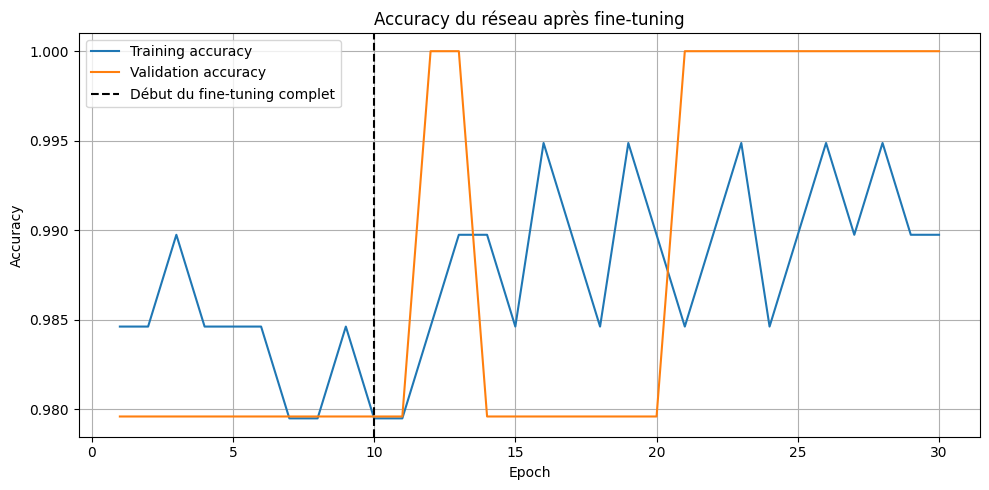

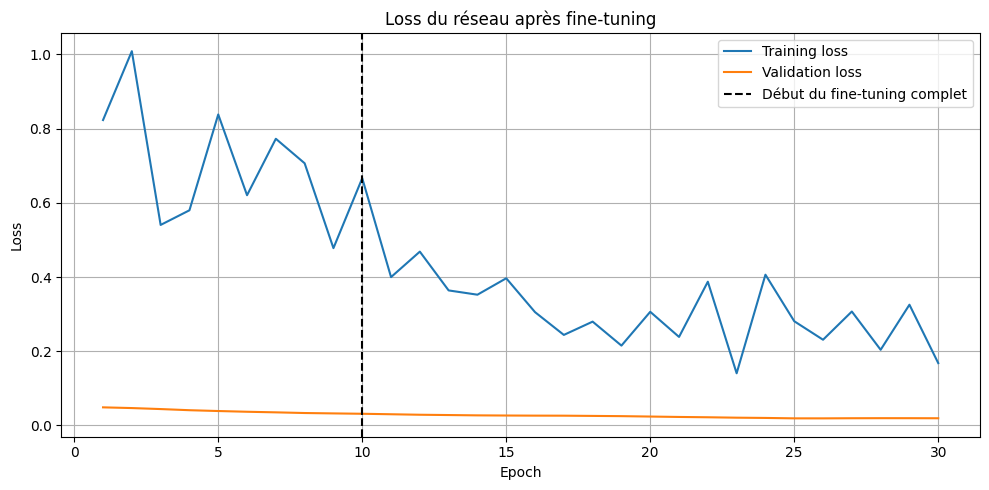

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Métriques - Validation après fine-tuning


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


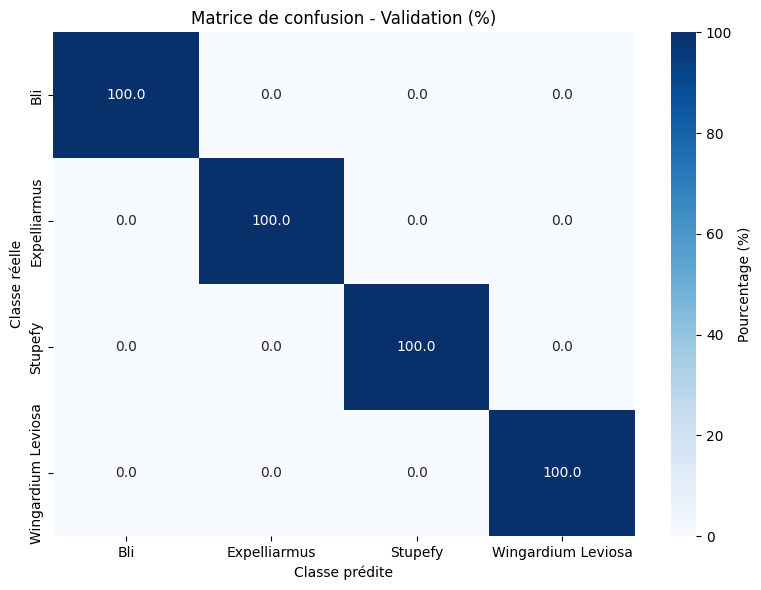

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Métriques - Test après fine-tuning


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


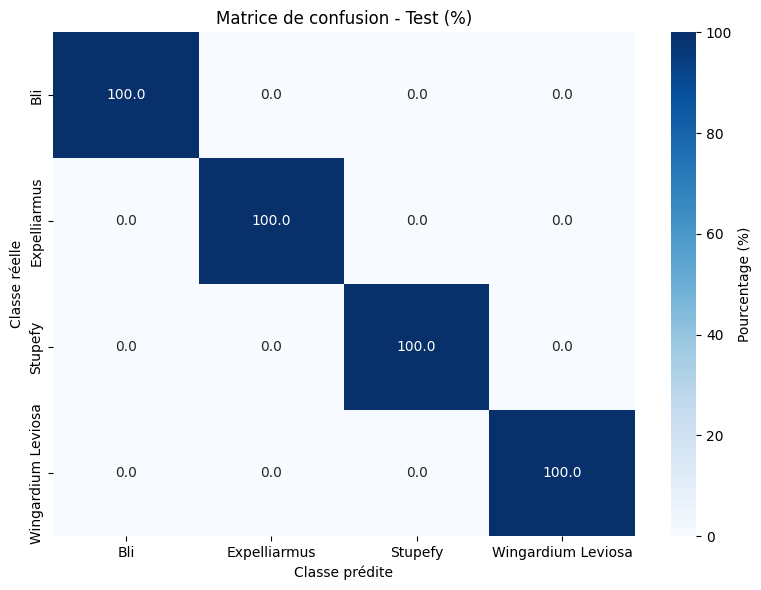


Fine-tuning terminé.
Anciennes classes : ['Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Nouvelles classes : ['Bli', 'Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Classes ajoutées : ['Bli']
Nouveau(x) label(s) : ['Bli']
Classes embarquées : ['Bli', 'Expelliarmus', 'Stupefy', 'Wingardium Leviosa']


In [47]:
model, scaler, label_encoder, resultats_finetuning = (
    nouveau_label.fine_tuner_avec_nouveau_label(
        model_base=model,
        scaler_base=scaler,
        label_encoder_base=label_encoder,
        dataset=data,
        fonction_construire_features=pretraitement.construire_features,
        epochs_tete=10,
        epochs_completes=20,
        batch_size=16,
        random_state=42,
    )
)

print(
    "Nouveau(x) label(s) :",
    resultats_finetuning["labels_ajoutes"],
)

print(
    "Classes embarquées :",
    list(label_encoder.classes_),
)

## 4. Ré-embarquer le modèle adapté

La cellule suivante régénère `model_params.h` avec la classe supplémentaire, puis reprend exactement la compilation, le téléversement et le moniteur série de la partie 2.

Après le téléversement, la légende du moniteur série doit contenir le nouveau label et son nombre de clignotements.


In [58]:
import importlib
import nouveau_label
import deploiement

importlib.reload(nouveau_label)

<module 'nouveau_label' from 'U:\\Stage IA\\Jupyter notebook\\Sujet TP\\nouveau_label.py'>

In [61]:
resultats_deploiement = (
    nouveau_label.exporter_et_deployer_modele_xiao(
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        arduino_code=nouveau_label.arduino_code,

        fonction_exporter=deploiement.exporter_modele_cpp,
        fonction_deployer=deploiement.deployer_modele_xiao,

        arduino_cli=ARDUINO_CLI,
        fichier_parametres="model_params.h",
        ouvrir_moniteur=True,
    )
)

Arduino CLI utilisé : .\arduino-cli.EXE

===== EXPORT DU MODÈLE =====
Fichier généré : \\netapp2\bassant-koum\Stage IA\Jupyter notebook\Sujet TP\model_params.h
Architecture : 138 -> 64 -> 32 -> 4
Labels : ['Bli', 'Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Paramètres exportés : 11108
Mémoire approximative des poids en float32 : 43.4 Kio

===== DÉPLOIEMENT SUR LA CARTE =====
Sketch généré : C:\temp\deploiement_xiao_cpp\deploiement_xiao_cpp.ino
Carte détectée : COM10 - Périphérique série USB (COM10)
Compilation en cours...
Compilation réussie.
Téléversement en cours...
Téléversement réussie.
Modèle correctement téléversé sur COM10
Ouverture du moniteur série...
Interrompez la cellule pour le fermer.

XIAO prete - inference C++ directe.
Correspondance labels / clignotements :
Bli : 1 clignotement
Expelliarmus : 2 clignotements
Stupefy : 3 clignotements
Wingardium Leviosa : 4 clignotements
Preparez le geste...
Sort reconnu : Bli | Score : 0.5914 | Clignotements attendus : 1
Preparez l

# **FIN DU TP**